# Data Augmentation Pipeline — Yogita Alone (CS24D017)


**Project:** Data Augmentation (Rotation, Flip, Crop) for Image Classifier to Reduce Overfitting

**My part:** Load CIFAR-10 dataset, build augmented and baseline transforms.

## Step 1: Install & Import Libraries

In [ ]:
!pip install torch torchvision matplotlib --quiet

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

## Step 2: Define Transforms

Two versions: one WITH augmentation (rotation, flip, crop), one WITHOUT (baseline) — needed for comparison later.

In [ ]:
# Augmented transform: rotation + horizontal flip + random crop
augmented_transform = transforms.Compose([
    transforms.RandomRotation(15),             # rotate randomly between -15 and +15 degrees
    transforms.RandomHorizontalFlip(p=0.5),     # 50% chance of horizontal flip
    transforms.RandomCrop(32, padding=4),       # pad then randomly crop back to 32x32
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Baseline transform: no augmentation, just tensor + normalize
baseline_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print("Transforms defined successfully.")

Transforms defined successfully.


## Step 3: Load CIFAR-10 Dataset

Downloads automatically (~170MB) — no manual dataset download needed.

In [ ]:
train_aug = datasets.CIFAR10(root='./data', train=True, download=True, transform=augmented_transform)
train_base = datasets.CIFAR10(root='./data', train=True, download=True, transform=baseline_transform)
test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=baseline_transform)

print(f"Full training set size: {len(train_aug)}")
print(f"Test set size: {len(test_set)}")

100%|██████████| 170M/170M [38:52<00:00, 73.1kB/s]


Full training set size: 50000
Test set size: 10000


## Step 4: Take a Small Subset

Using a small subset (2000 images) makes the model overfit faster on the baseline — which is exactly what we want to demonstrate augmentation fixing.

In [ ]:
SUBSET_SIZE = 2000

train_aug = torch.utils.data.Subset(train_aug, range(SUBSET_SIZE))
train_base = torch.utils.data.Subset(train_base, range(SUBSET_SIZE))

print(f"Using subset of {SUBSET_SIZE} images for training.")

Using subset of 2000 images for training.


## Step 5: Create DataLoaders

These three loaders (`loader_aug`, `loader_base`, `test_loader`) are the final output.

In [ ]:
loader_aug = DataLoader(train_aug, batch_size=64, shuffle=True)
loader_base = DataLoader(train_base, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

print("DataLoaders ready: loader_aug, loader_base, test_loader")

DataLoaders ready: loader_aug, loader_base, test_loader


## Step 6: Verify Augmentation Visually

Save a sample image to show the augmentation is actually working.

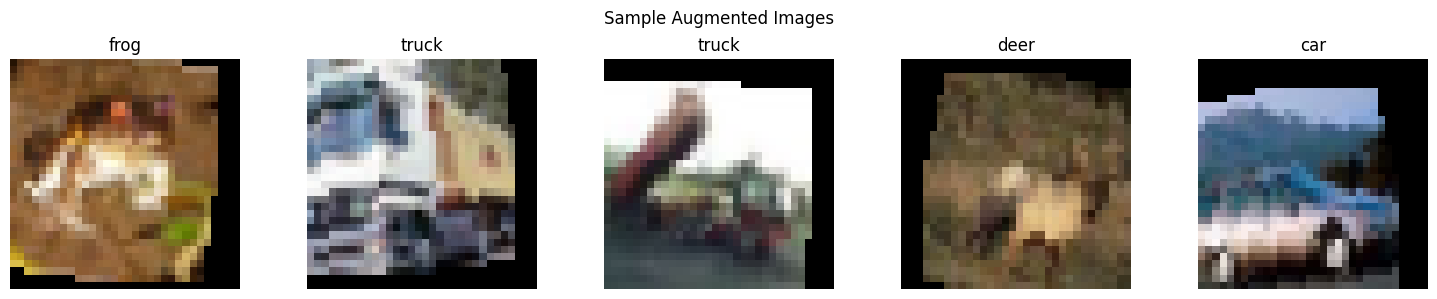

Saved sample_augmented.png — use this in the README/report.


In [ ]:
 classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img, label = train_aug[i]
    img_display = img.permute(1, 2, 0) * 0.5 + 0.5  # unnormalize for display
    axes[i].imshow(img_display)
    axes[i].set_title(classes[label])
    axes[i].axis('off')

plt.suptitle('Sample Augmented Images')
plt.tight_layout()
plt.savefig('sample_augmented.png')
plt.show()

print("Saved sample_augmented.png — use this in the README/report.")

# CNN Model + Training — Srushti Belsare (CS23165)

**Project:** Data Augmentation (Rotation, Flip, Crop) for Image Classifier to Reduce Overfitting

**My part:** Build CNN architecture, train baseline and augmented models, and save training results.

CNN Architecture

In [ ]:
# Step 7: Build CNN Model

import torch.nn as nn
import torch.optim as optim

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # Convolution + ReLU + Pooling
        self.conv_layers = nn.Sequential(

            # Conv Layer 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Conv Layer 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Conv Layer 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        # Flatten + Dense Layers
        self.fc_layers = nn.Sequential(
            nn.Flatten(),

            # 32x32 -> 16x16 -> 8x8 -> 4x4
            nn.Linear(128 * 4 * 4, 128),

            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


model = CNNModel().to(device)

print(model)

Using device: cpu
CNNModel(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [25]:
# Step 8: Training Function

def train_model(model, train_loader, epochs=20):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    train_accuracies = []

    model.to(device)

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * correct / total

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {epoch_loss:.4f} "
            f"Accuracy: {epoch_accuracy:.2f}%"
        )

    return train_losses, train_accuracies

In [27]:
 # Step 9: Train Baseline Model (Without Augmentation)

baseline_model = CNNModel().to(device)

baseline_losses, baseline_accuracies = train_model(
    baseline_model,
    loader_base,
    epochs=20
)

print("Baseline training completed.")

Epoch [1/20] Loss: 2.1368 Accuracy: 20.50%
Epoch [2/20] Loss: 1.8723 Accuracy: 32.05%
Epoch [3/20] Loss: 1.7017 Accuracy: 36.95%
Epoch [4/20] Loss: 1.5775 Accuracy: 41.95%
Epoch [5/20] Loss: 1.4619 Accuracy: 46.00%
Epoch [6/20] Loss: 1.3689 Accuracy: 49.80%
Epoch [7/20] Loss: 1.2723 Accuracy: 53.90%
Epoch [8/20] Loss: 1.1906 Accuracy: 57.75%
Epoch [9/20] Loss: 1.0804 Accuracy: 61.55%
Epoch [10/20] Loss: 0.9873 Accuracy: 64.70%
Epoch [11/20] Loss: 0.8771 Accuracy: 69.40%
Epoch [12/20] Loss: 0.7904 Accuracy: 72.15%
Epoch [13/20] Loss: 0.7028 Accuracy: 74.55%
Epoch [14/20] Loss: 0.5987 Accuracy: 78.90%
Epoch [15/20] Loss: 0.5002 Accuracy: 83.05%
Epoch [16/20] Loss: 0.4498 Accuracy: 85.60%
Epoch [17/20] Loss: 0.2970 Accuracy: 90.70%
Epoch [18/20] Loss: 0.2509 Accuracy: 92.30%
Epoch [19/20] Loss: 0.1998 Accuracy: 94.20%
Epoch [20/20] Loss: 0.1541 Accuracy: 95.80%
Baseline training completed.


In [29]:
# Step 10: Train Augmented Model

augmented_model = CNNModel().to(device)

augmented_losses, augmented_accuracies = train_model(
    augmented_model,
    loader_aug,
    epochs=20
)

print("Augmented training completed.")

Epoch [1/20] Loss: 2.1939 Accuracy: 18.60%
Epoch [2/20] Loss: 2.0025 Accuracy: 25.55%
Epoch [3/20] Loss: 1.9390 Accuracy: 27.90%
Epoch [4/20] Loss: 1.8029 Accuracy: 34.20%
Epoch [5/20] Loss: 1.7248 Accuracy: 36.25%
Epoch [6/20] Loss: 1.6931 Accuracy: 37.40%
Epoch [7/20] Loss: 1.6095 Accuracy: 40.90%
Epoch [8/20] Loss: 1.5549 Accuracy: 42.00%
Epoch [9/20] Loss: 1.5014 Accuracy: 44.35%
Epoch [10/20] Loss: 1.5078 Accuracy: 43.50%
Epoch [11/20] Loss: 1.4406 Accuracy: 47.30%
Epoch [12/20] Loss: 1.4494 Accuracy: 47.45%
Epoch [13/20] Loss: 1.4068 Accuracy: 49.30%
Epoch [14/20] Loss: 1.3893 Accuracy: 48.50%
Epoch [15/20] Loss: 1.3668 Accuracy: 49.10%
Epoch [16/20] Loss: 1.3262 Accuracy: 51.40%
Epoch [17/20] Loss: 1.2784 Accuracy: 53.05%
Epoch [18/20] Loss: 1.2749 Accuracy: 53.50%
Epoch [19/20] Loss: 1.2701 Accuracy: 54.40%
Epoch [20/20] Loss: 1.2191 Accuracy: 55.45%
Augmented training completed.


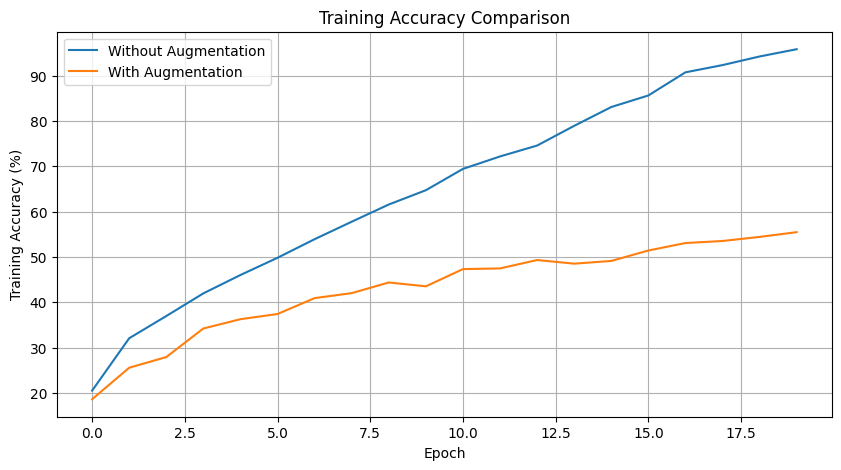

In [30]:
# Step 11: Compare Training Accuracy

plt.figure(figsize=(10, 5))

plt.plot(
    baseline_accuracies,
    label="Without Augmentation"
)

plt.plot(
    augmented_accuracies,
    label="With Augmentation"
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Training Accuracy Comparison")

plt.legend()
plt.grid(True)
plt.show()

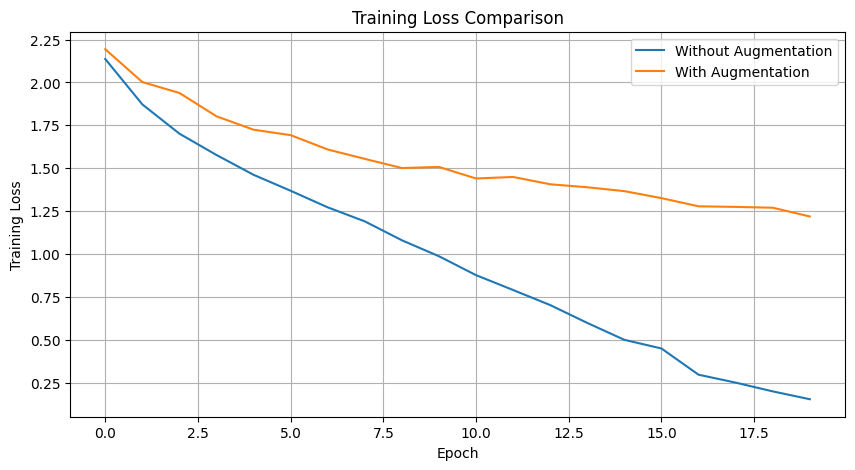

In [31]:
# Step 12: Compare Training Loss

plt.figure(figsize=(10, 5))

plt.plot(
    baseline_losses,
    label="Without Augmentation"
)

plt.plot(
    augmented_losses,
    label="With Augmentation"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")

plt.legend()
plt.grid(True)
plt.show()

In [32]:
# Step 13: Evaluation Function

def evaluate_model(model, test_loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return accuracy

In [33]:
# Step 14: Test Accuracy Comparison

baseline_test_accuracy = evaluate_model(
    baseline_model,
    test_loader
)

augmented_test_accuracy = evaluate_model(
    augmented_model,
    test_loader
)

print(f"Baseline Test Accuracy: {baseline_test_accuracy:.2f}%")
print(f"Augmented Test Accuracy: {augmented_test_accuracy:.2f}%")

Baseline Test Accuracy: 48.19%
Augmented Test Accuracy: 45.53%


In [34]:
# Step 15: Final Comparison

print("\n===== FINAL RESULTS =====")

print(
    f"Without Augmentation : "
    f"{baseline_test_accuracy:.2f}%"
)

print(
    f"With Augmentation    : "
    f"{augmented_test_accuracy:.2f}%"
)

improvement = augmented_test_accuracy - baseline_test_accuracy

print(
    f"Improvement          : "
    f"{improvement:.2f}%"
)


===== FINAL RESULTS =====
Without Augmentation : 48.19%
With Augmentation    : 45.53%
Improvement          : -2.66%


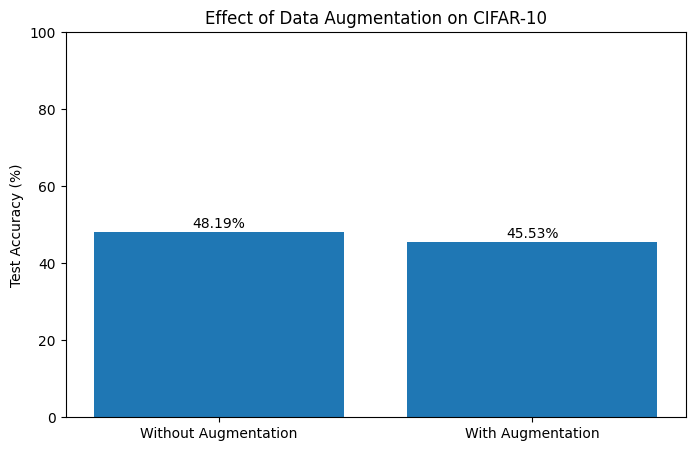

In [35]:
# Step 16: Accuracy Comparison Graph

methods = [
    "Without Augmentation",
    "With Augmentation"
]

accuracies = [
    baseline_test_accuracy,
    augmented_test_accuracy
]

plt.figure(figsize=(8, 5))

plt.bar(methods, accuracies)

plt.ylabel("Test Accuracy (%)")
plt.title("Effect of Data Augmentation on CIFAR-10")

plt.ylim(0, 100)

for i, value in enumerate(accuracies):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

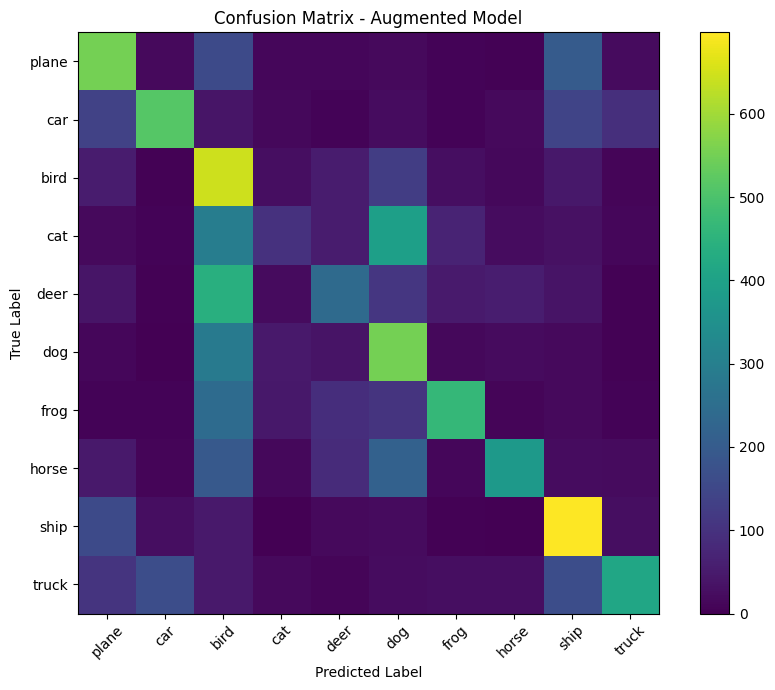

In [36]:
# Step 17: Confusion Matrix for Augmented Model

import numpy as np

classes = [
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

augmented_model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = augmented_model(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())


conf_matrix = np.zeros((10, 10), dtype=int)

for true_label, predicted_label in zip(
    all_labels,
    all_predictions
):
    conf_matrix[true_label, predicted_label] += 1


plt.figure(figsize=(9, 7))

plt.imshow(conf_matrix)

plt.colorbar()

plt.xticks(
    range(10),
    classes,
    rotation=45
)

plt.yticks(
    range(10),
    classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Augmented Model")

plt.tight_layout()
plt.show()

## Step 18: Conclusion

The CIFAR-10 dataset was trained using two approaches:

1. Without data augmentation
2. With rotation, horizontal flipping and random cropping

The training and testing results were compared to study the effect of data augmentation on overfitting.

Data augmentation creates different variations of training images and helps the model learn more general features. Therefore, it can improve generalization and reduce the risk of overfitting.